# Sven (JAX / Flax) vs Adam: Toy 1D Regression

This notebook mirrors `toy_1d_regression.ipynb` but uses the JAX port of Sven
(`sven.jax`). The target function is $f(x) = e^{-10x^2}\sin(2x)$.

The JAX port is a near drop-in replacement for the PyTorch version:

1. Wrap your apply_fn + params with `SvenWrapper`.
2. Create a `Sven` optimizer.
3. Call `wrapped.loss_and_grad(batch)` each step (replaces `loss.backward()`),
   then `optimizer.step()`.

The only new ingredient is efficient masked Jacobians: when
`param_fraction < 1.0`, the JAX implementation differentiates **only** the
active slice of the flat parameter vector (the frozen portion is hidden
behind `jax.lax.stop_gradient`). You get a genuine `(B, f*P)` Jacobian
— not a `(B, P)` Jacobian that secretly wasted compute on frozen
entries.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import flax.linen as nn
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

from sven.jax import SvenWrapper, Sven

print(jax.devices())

[CpuDevice(id=0)]


## Dataset

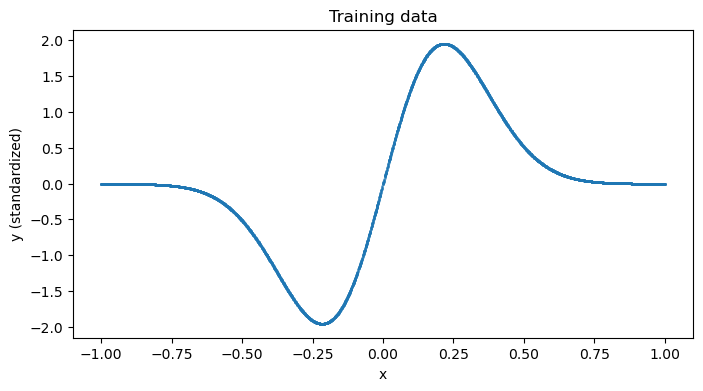

In [2]:
def target_fn(x):
    return jnp.exp(-10 * x ** 2) * jnp.sin(2 * x)

rng = np.random.default_rng(0)
n_train, n_val = 10_000, 10_000
xtrain = jnp.asarray(rng.uniform(-1, 1, size=(n_train, 1)), dtype=jnp.float32)
xval = jnp.asarray(rng.uniform(-1, 1, size=(n_val, 1)), dtype=jnp.float32)
ytrain = target_fn(xtrain)
yval = target_fn(xval)

mean, std = ytrain.mean(), ytrain.std()
ytrain = (ytrain - mean) / std
yval = (yval - mean) / std

batch_size = 128

def batches(x, y, bs, key):
    perm = jax.random.permutation(key, x.shape[0])
    for i in range(0, x.shape[0] - bs + 1, bs):
        idx = perm[i:i+bs]
        yield x[idx], y[idx]

plt.figure(figsize=(8, 4))
plt.scatter(np.asarray(xtrain), np.asarray(ytrain), s=1, alpha=0.3)
plt.xlabel('x'); plt.ylabel('y (standardized)'); plt.title('Training data')
plt.show()

## Define the model (Flax Linen MLP)

In [3]:
class MLP(nn.Module):
    hidden_dims: tuple = (16, 16, 16)
    out_dim: int = 1

    @nn.compact
    def __call__(self, x):
        for h in self.hidden_dims:
            x = nn.gelu(nn.Dense(h)(x))
        return nn.Dense(self.out_dim)(x)

model = MLP()
init_key = jax.random.PRNGKey(42)
params_init = model.init(init_key, xtrain[:1])
n_params = sum(p.size for p in jax.tree_util.tree_leaves(params_init))
print(f'Parameters: {n_params}')

Parameters: 593


## Train with Adam (optax)

In [4]:
def mse(params, x, y):
    return jnp.mean((model.apply(params, x) - y) ** 2)

adam_params = params_init
adam_opt = optax.adam(1e-3)
adam_state = adam_opt.init(adam_params)

@jax.jit
def adam_step(params, state, x, y):
    loss, grads = jax.value_and_grad(mse)(params, x, y)
    updates, state = adam_opt.update(grads, state, params)
    params = optax.apply_updates(params, updates)
    return params, state, loss

num_epochs = 100
losses_adam = defaultdict(list)
losses_adam['val'].append(float(mse(adam_params, xval, yval)))

key = jax.random.PRNGKey(0)
for epoch in tqdm(range(num_epochs)):
    key, sub = jax.random.split(key)
    ep_train = []
    for xb, yb in batches(xtrain, ytrain, batch_size, sub):
        adam_params, adam_state, loss = adam_step(adam_params, adam_state, xb, yb)
        ep_train.append(float(loss))
    losses_adam['train'].append(np.mean(ep_train))
    losses_adam['val'].append(float(mse(adam_params, xval, yval)))

100%|██████████| 100/100 [00:03<00:00, 25.26it/s]


## Train with Sven

Key differences from the Adam loop:
1. Wrap `model.apply` + `params` with `SvenWrapper`, passing a **per-sample** loss function.
2. `wrapped.loss_and_grad(batch)` replaces `jax.value_and_grad` — it computes the per-sample Jacobian internally.
3. `optimizer.step()` applies the SVD-pseudo-inverse update.

In [5]:
def persample_mse(pred, y):
    # Must return shape (B,), NOT a scalar.
    return jnp.sum((pred - y) ** 2, axis=-1)

wrapped = SvenWrapper(model.apply, params_init, persample_mse)
sven_opt = Sven(wrapped, lr=0.1, k=batch_size // 2, rtol=1e-3)

def eval_mse():
    return float(persample_mse(wrapped.evaluate(xval), yval).mean())

losses_sven = defaultdict(list)
losses_sven['val'].append(eval_mse())

key = jax.random.PRNGKey(0)
for epoch in tqdm(range(num_epochs)):
    key, sub = jax.random.split(key)
    ep_train = []
    for xb, yb in batches(xtrain, ytrain, batch_size, sub):
        batch_losses, _ = wrapped.loss_and_grad((xb, yb))
        sven_opt.step()
        ep_train.append(float(batch_losses.mean()))
    losses_sven['train'].append(np.mean(ep_train))
    losses_sven['val'].append(eval_mse())

100%|██████████| 100/100 [00:17<00:00,  5.65it/s]


## Compare results

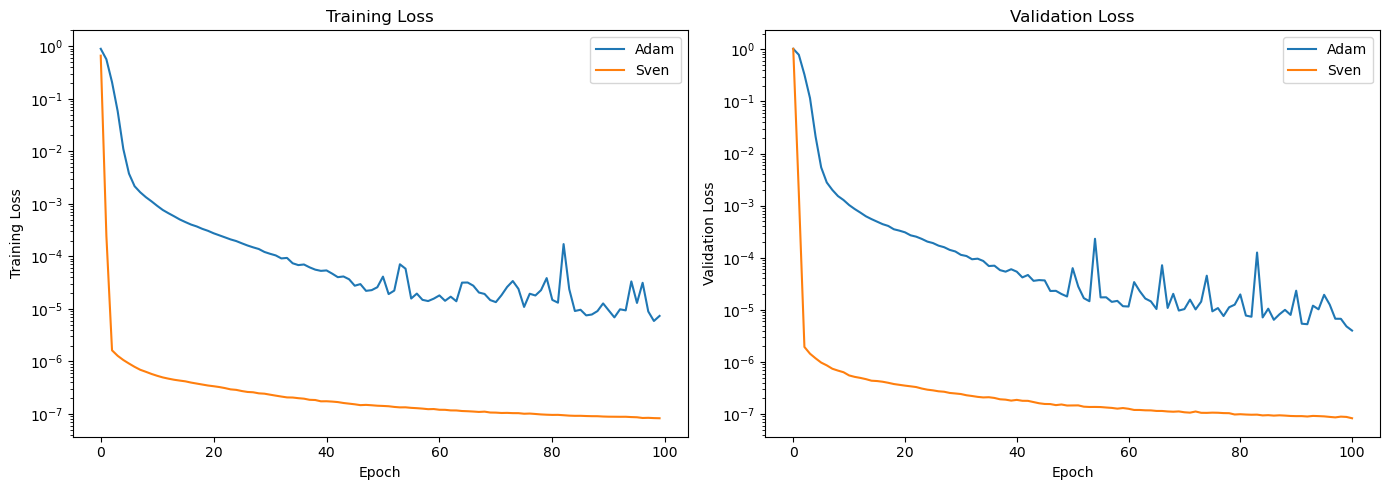

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(losses_adam['train'], label='Adam')
axes[0].plot(losses_sven['train'], label='Sven')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].set_title('Training Loss')

axes[1].plot(losses_adam['val'], label='Adam')
axes[1].plot(losses_sven['val'], label='Sven')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Loss')
axes[1].set_yscale('log'); axes[1].legend(); axes[1].set_title('Validation Loss')
plt.tight_layout(); plt.show()

## Visualize predictions

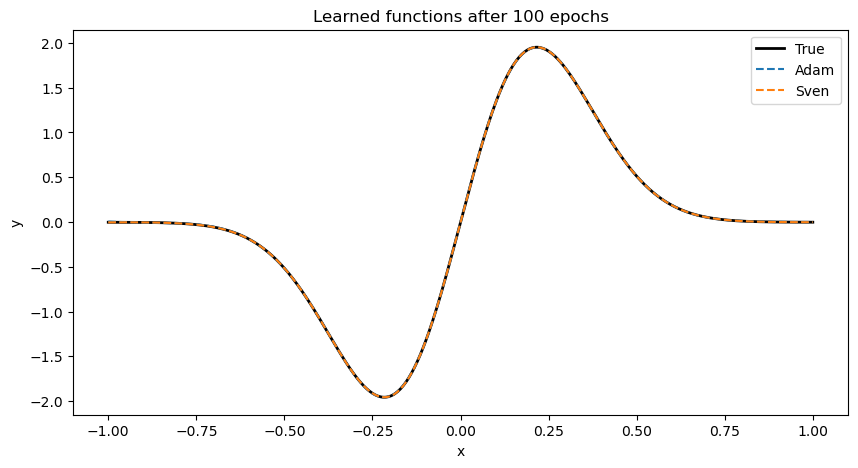

In [7]:
x_plot = jnp.linspace(-1, 1, 500)[:, None]
y_true = (target_fn(x_plot) - mean) / std
y_adam = model.apply(adam_params, x_plot)
y_sven = wrapped.evaluate(x_plot)

plt.figure(figsize=(10, 5))
plt.plot(np.asarray(x_plot), np.asarray(y_true), 'k-', lw=2, label='True')
plt.plot(np.asarray(x_plot), np.asarray(y_adam), '--', lw=1.5, label='Adam')
plt.plot(np.asarray(x_plot), np.asarray(y_sven), '--', lw=1.5, label='Sven')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('Learned functions after 100 epochs'); plt.show()

## Partial-parameter updates (`param_fraction < 1.0`)

For large networks it is often wasteful (and memory-prohibitive) to compute
the Jacobian w.r.t. every parameter at every step. `SvenWrapper` supports
sampling a random subset of parameters each step via `param_fraction`.

**Efficiency note.** The PyTorch version still computes the full-rank Jacobian
under the hood and indexes it afterwards — so `param_fraction < 1` buys you
nothing in compute, only in the downstream SVD. The JAX version
differentiates **only** the active slice: the frozen portion of the flat
parameter vector is wrapped in `jax.lax.stop_gradient` and the active slice
is scattered back in with `.at[indices].set(...)`. Reverse-mode AD never
materialises cotangents for frozen entries, so the Jacobian is genuinely
`(B, f*P)`.

big model params: 8513
n_params=8513  n_active=851
Jacobian shape (B, n_active): (128, 851)


100%|██████████| 50/50 [00:17<00:00,  2.86it/s]


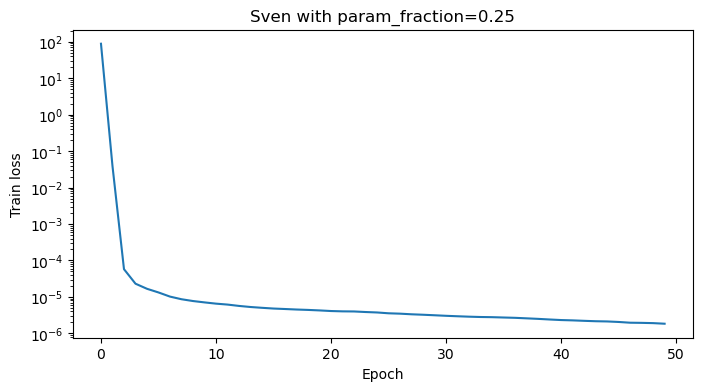

In [ ]:
# Bigger model to make masking actually matter
big_model = MLP(hidden_dims=(64, 64, 64))
big_params = big_model.init(jax.random.PRNGKey(42), xtrain[:1])
print('big model params:', sum(p.size for p in jax.tree_util.tree_leaves(big_params)))

wrapped_partial = SvenWrapper(
    big_model.apply, big_params, persample_mse,
    param_fraction=0.25,     # update 25% of parameters per step
    mask_by_block=False,     # elementwise subset — set True to keep whole Dense layers together
)
opt_partial = Sven(wrapped_partial, lr=0.1, k=batch_size // 2, rtol=1e-3)
print(f'n_params={wrapped_partial.n_params}  n_active={wrapped_partial.n_active}')

# A single step, to peek at Jacobian shape
key = jax.random.PRNGKey(7)
xb, yb = xtrain[:batch_size], ytrain[:batch_size]
losses, _ = wrapped_partial.loss_and_grad((xb, yb), key=key)
print('Jacobian shape (B, n_active):', wrapped_partial.jac.shape)
opt_partial.step()

# Short training run with masking
losses_partial = []
for epoch in tqdm(range(50)):
    key, sub = jax.random.split(key)
    ep = []
    for xb, yb in batches(xtrain, ytrain, batch_size, sub):
        key, sub2 = jax.random.split(key)
        batch_losses, _ = wrapped_partial.loss_and_grad((xb, yb), key=sub2)
        opt_partial.step()
        ep.append(float(batch_losses.mean()))
    losses_partial.append(np.mean(ep))

plt.figure(figsize=(8, 4))
plt.plot(losses_partial)
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Train loss')
plt.title('Sven with param_fraction=0.25'); plt.show()

In [9]:
# Bigger model to make masking actually matter
big_model = MLP(hidden_dims=(64, 64, 64))
big_params = big_model.init(jax.random.PRNGKey(42), xtrain[:1])
print('big model params:', sum(p.size for p in jax.tree_util.tree_leaves(big_params)))

wrapped_partial = SvenWrapper(
    big_model.apply, big_params, persample_mse,
    param_fraction=1.0,     # update 100% of parameters per step (baseline)
    mask_by_block=False,     # elementwise subset — set True to keep whole Dense layers together
)
opt_partial = Sven(wrapped_partial, lr=0.1, k=batch_size // 2, rtol=1e-3)
print(f'n_params={wrapped_partial.n_params}  n_active={wrapped_partial.n_active}')

# A single step, to peek at Jacobian shape
key = jax.random.PRNGKey(7)
xb, yb = xtrain[:batch_size], ytrain[:batch_size]
losses, _ = wrapped_partial.loss_and_grad((xb, yb), key=key)
print('Jacobian shape (B, n_active):', wrapped_partial.jac.shape)
opt_partial.step()

# Short training run with masking
losses_partial = []
for epoch in tqdm(range(50)):
    key, sub = jax.random.split(key)
    ep = []
    for xb, yb in batches(xtrain, ytrain, batch_size, sub):
        key, sub2 = jax.random.split(key)
        batch_losses, _ = wrapped_partial.loss_and_grad((xb, yb), key=sub2)
        opt_partial.step()
        ep.append(float(batch_losses.mean()))
    losses_partial.append(np.mean(ep))

plt.figure(figsize=(8, 4))
plt.plot(losses_partial)
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Train loss')
plt.title('Sven with param_fraction=0.25'); plt.show()

big model params: 8513
n_params=8513  n_active=8513
Jacobian shape (B, n_active): (128, 8513)


 50%|█████     | 25/50 [00:17<00:17,  1.44it/s]


KeyboardInterrupt: 